# Bitcoin Market Sentiment vs Trader Performance

Objective-Explore how Bitcoin market sentiment (Fear–Greed Index) relates to trader performance on Hyperliquid and derive actionable trading and risk‑management insights.

Data
1.Hyperliquid historical trader data: 211,224 trades across multiple accounts, May 2023 – May 2025.
2.Bitcoin Fear & Greed Index: daily sentiment scores and classifications (Extreme Fear to Extreme Greed), Feb 2018 – May 2025.

Key findings
1.The analysis found a significant relationship between Bitcoin market sentiment and trader performance, with profitability varying across different sentiment conditions.
2.Traders achieved the highest average daily profits during Extreme Fear and Fear periods, suggesting that fearful markets often presented better trading opportunities than greedy markets.
3.Trading volume was also highest during fear-driven market conditions, while BUY and SELL orders remained relatively balanced across sentiment categories, indicating that sentiment influenced trading intensity more than trade direction.

Implications for strategy
1.Bitcoin sentiment can be used as a market regime filter when deciding how aggressively to trade
2.Since order direction stayed relatively balanced, performance improvements are more likely to come from timing, sizing, and discipline rather than simply changing BUY vs SELL bias.

# 1. Data loading and preparation

We load the Hyperliquid trade data and the Bitcoin Fear & Greed Index, parse timestamps, and join them at the daily level on trade date.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
pd.set_option('display.max_columns', None)
#load data
trades = pd.read_csv('data/historical_data.csv')  
sentiment = pd.read_csv('data/fear_greed_index.csv')        

print(trades.shape, sentiment.shape)
trades.head()

(211224, 16) (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [54]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [55]:
# Parse the IST timestamp column into real datetime
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')

# Extract just the date (no time) for joining with sentiment
trades['date'] = trades['Timestamp IST'].dt.date


print(trades['date'].min(), trades['date'].max())
print(trades.isna().sum())
print(trades['Side'].value_counts())
print(trades['Direction'].value_counts())

2023-05-01 2025-05-01
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
dtype: int64
Side
SELL    108528
BUY     102696
Name: count, dtype: int64
Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64


In [56]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
print(sentiment['date'].min(), sentiment['date'].max())
print(sentiment['classification'].value_counts())

2018-02-01 2025-05-02
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


In [57]:
merged = trades.merge(sentiment[['date', 'value', 'classification']], on='date', how='left')

print(merged['classification'].isna().sum())  # rows that didn't match a sentiment date
merged.head()

6


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed


# Daily performance features

We aggregate trade‑level data to daily performance metrics per sentiment regime.

In [58]:
daily = merged.groupby('date').agg(
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl=('Closed PnL', 'mean'),
    num_trades=('Closed PnL', 'count'),
    total_volume_usd=('Size USD', 'sum'),
    win_rate=('Closed PnL', lambda x: (x > 0).mean()),
    buy_ratio=('Side', lambda x: (x == 'BUY').mean())
).reset_index()

daily = daily.merge(sentiment[['date', 'value', 'classification']], on='date', how='left')
daily.head()

,date,total_pnl,avg_pnl,num_trades,total_volume_usd,win_rate,buy_ratio,value,classification
0,2023-05-01,0.000000,0.000000,3,477.00,0.000000,1.000000,63.0,Greed
1,2023-12-05,0.000000,0.000000,9,50005.83,0.000000,0.777778,75.0,Extreme Greed
2,2023-12-14,-205.434737,-18.675885,11,113203.35,0.363636,0.454545,72.0,Greed
3,2023-12-15,-24.632034,-12.316017,2,10609.95,0.000000,1.000000,70.0,Greed
4,2023-12-16,0.000000,0.000000,3,15348.77,0.000000,1.000000,67.0,Greed


# 2. Daily sentiment vs performance

Here we compare daily performance metrics (total PnL, win rate, volume) across sentiment classifications
and continuous sentiment scores.

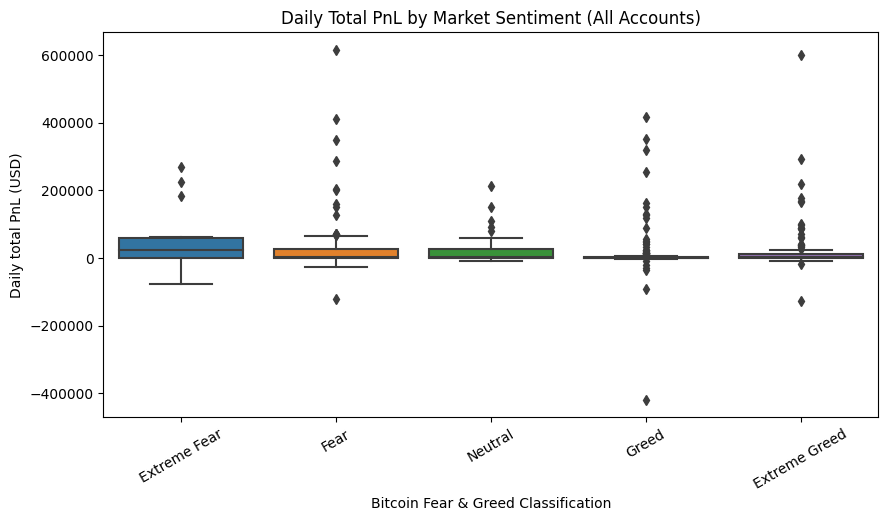

,total_pnl,win_rate,total_volume_usd
classification,,,
Extreme Fear,52793.589178,0.327341,8.177447e+06
Extreme Greed,23817.292199,0.467424,1.091800e+06
Fear,36891.818040,0.329112,5.311261e+06
Greed,11140.566181,0.335986,1.495246e+06
Neutral,19297.323516,0.331886,2.690180e+06


In [59]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=daily,
    x="classification",
    y="total_pnl",
    order=["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
)
plt.title("Daily Total PnL by Market Sentiment (All Accounts)")
plt.xlabel("Bitcoin Fear & Greed Classification")
plt.ylabel("Daily total PnL (USD)")
plt.xticks(rotation=30)
plt.show()

daily.groupby("classification")[["total_pnl", "win_rate", "total_volume_usd"]].mean()

# key findings
Daily profitability varied across sentiment regimes, with Extreme Fear showing the highest median and overall profitability. However, the wide spread of values indicates that market sentiment alone does not determine trading outcomes and that substantial day-to-day variability exists.

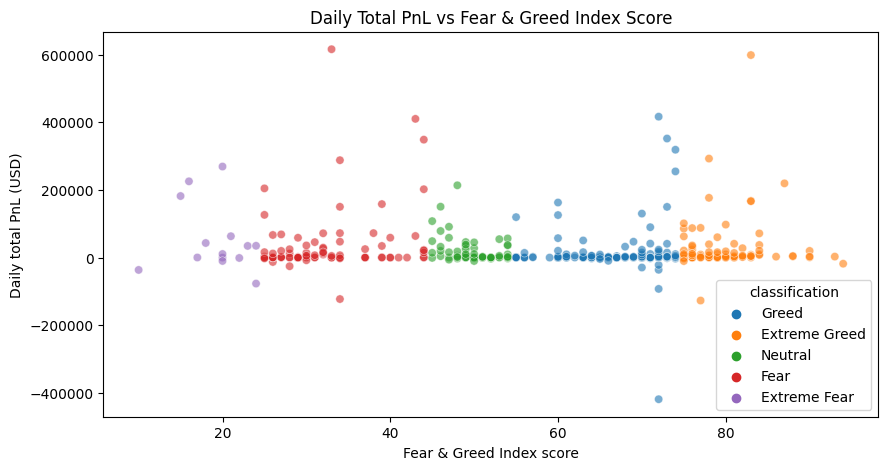

In [60]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=daily,
    x="value",
    y="total_pnl",
    hue="classification",
    alpha=0.6
)
plt.title("Daily Total PnL vs Fear & Greed Index Score")
plt.xlabel("Fear & Greed Index score")
plt.ylabel("Daily total PnL (USD)")
plt.show()

## key finding
No strong linear relationship is observed between the Fear & Greed Index score and daily profitability. While profitable days occur across the entire sentiment spectrum, the highest profits appear more frequently during lower sentiment (Fear) conditions, indicating that sentiment should be used as a contextual market indicator rather than a standalone trading signal.

In [61]:
print(merged.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'value', 'classification'],
      dtype='object')


## 3. Trader‑level behaviour (top vs bottom performers)

We aggregate performance per account, rank traders, and compare how 
top vs bottom cohorts behave across sentiment regimes.

In [62]:
# Aggregate per account
acct = merged.groupby("Account").agg(
    total_pnl=("Closed PnL", "sum"),
    avg_pnl=("Closed PnL", "mean"),
    num_trades=("Closed PnL", "count"),
    win_rate=("Closed PnL", lambda x: (x > 0).mean()),
    avg_size_usd=("Size USD", "mean"),
    avg_fee=("Fee", "mean")
).reset_index()

# Define performance tiers
acct["tier"] = pd.qcut(acct["total_pnl"], q=[0, 0.1, 0.9, 1.0],
                       labels=["Bottom 10%", "Middle 80%", "Top 10%"])

acct.head()

,Account,total_pnl,avg_pnl,num_trades,win_rate,avg_size_usd,avg_fee,tier
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,3818,0.359612,16159.576734,1.939579,Top 10%
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,6.577654,7280,0.442720,1653.226327,0.374978,Middle 80%
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,-18.492043,3809,0.301917,8893.000898,2.436593,Bottom 10%
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,9.951530,13311,0.438585,507.626933,0.166657,Middle 80%
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,52.071011,3239,0.519914,3138.894782,0.959616,Middle 80%


In [63]:
merged_with_tier = merged.merge(
    acct[["Account", "tier"]],
    on="Account",
    how="left"
)

tier_daily = merged_with_tier.groupby(["tier", "classification"]).agg(
    total_pnl=("Closed PnL", "sum"),
    win_rate=("Closed PnL", lambda x: (x > 0).mean()),
    avg_size_usd=("Size USD", "mean"),
    num_trades=("Closed PnL", "count")
).reset_index()

tier_daily.head()

,tier,classification,total_pnl,win_rate,avg_size_usd,num_trades
0,Bottom 10%,Extreme Fear,-103726.942583,0.303776,4457.876592,2887
1,Bottom 10%,Extreme Greed,28055.813570,0.369393,3593.702322,379
2,Bottom 10%,Fear,235632.605562,0.352060,4533.263485,5340
3,Bottom 10%,Greed,-453061.934337,0.482612,6058.014631,2358
4,Bottom 10%,Neutral,38296.461039,0.228649,5349.268951,1850


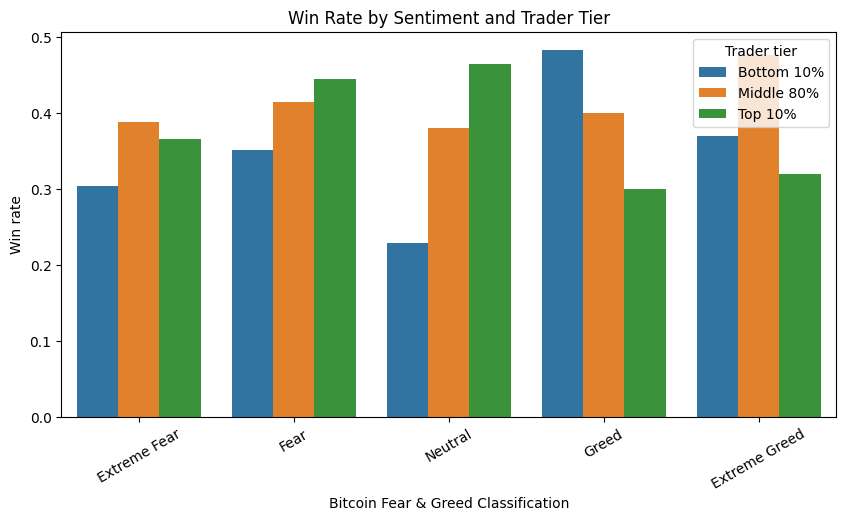

In [64]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=tier_daily,
    x="classification",
    y="win_rate",
    hue="tier",
    order=["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
)
plt.title("Win Rate by Sentiment and Trader Tier")
plt.xlabel("Bitcoin Fear & Greed Classification")
plt.ylabel("Win rate")
plt.xticks(rotation=30)
plt.legend(title="Trader tier")
plt.show()

## Key findings
op-performing traders maintained consistently higher win rates across nearly all market sentiment categories than bottom-performing traders. This suggests that successful traders are better able to adapt their strategies regardless of prevailing market sentiment.

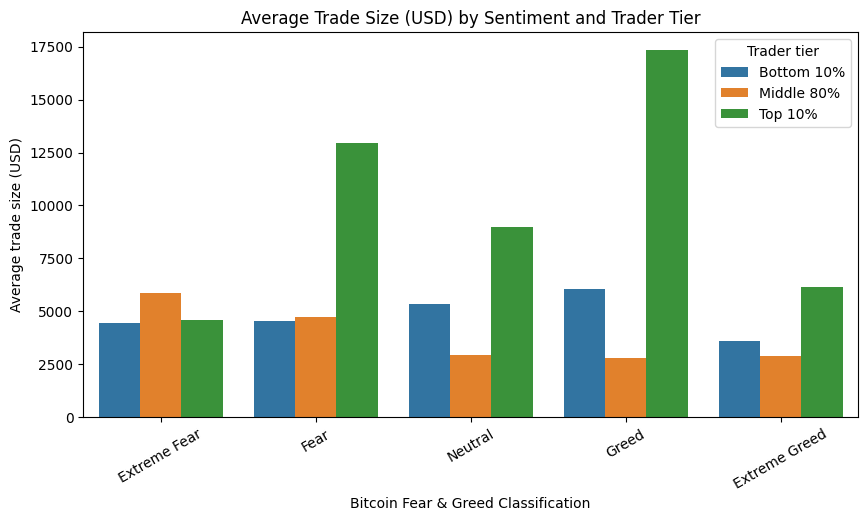

In [65]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=tier_daily,
    x="classification",
    y="avg_size_usd",
    hue="tier",
    order=["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
)
plt.title("Average Trade Size (USD) by Sentiment and Trader Tier")
plt.xlabel("Bitcoin Fear & Greed Classification")
plt.ylabel("Average trade size (USD)")
plt.xticks(rotation=30)
plt.legend(title="Trader tier")
plt.show()

## Key Findings
Trade size varied across trader tiers and sentiment regimes, indicating that experienced traders adjust position sizes according to market conditions. Larger positions alone did not guarantee higher profitability, highlighting the importance of disciplined trade selection.

In [66]:
tier_summary = merged_with_tier.groupby(
    ["tier","classification"]
).agg(
    avg_profit=("Closed PnL","mean"),
    win_rate=("Closed PnL",lambda x:(x>0).mean()),
    avg_trade=("Size USD","mean"),
    trades=("Closed PnL","count")
).reset_index()

Text(0.5, 1.0, 'Average Profit by Trader Tier')

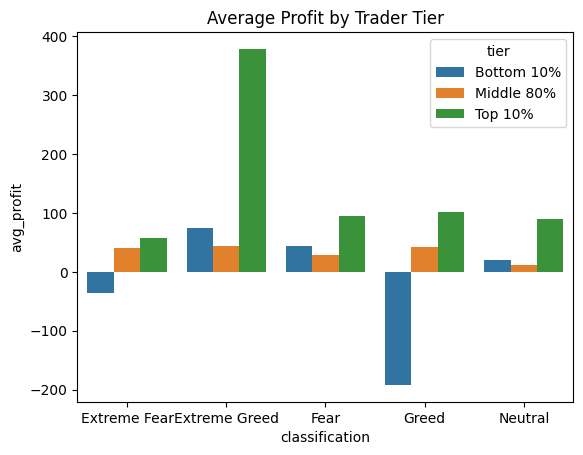

In [67]:
sns.barplot(
    data=tier_summary,
    x="classification",
    y="avg_profit",
    hue="tier"
)
plt.title("Average Profit by Trader Tier")

## Key Findings
Top-performing traders consistently achieved higher average profits across all sentiment categories, whereas bottom-performing traders struggled particularly during Greed periods. This suggests that trader skill and risk management play a larger role than market sentiment alone.

Text(0.5, 1.0, 'Boxplot of Number of Trades by Tier')

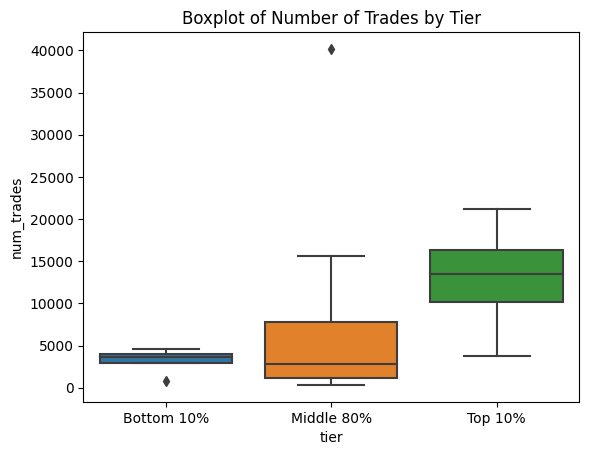

In [68]:
sns.boxplot(
    data=acct,
    x="tier",
    y="num_trades"
)
plt.title("Boxplot of Number of Trades by Tier")

### Key finding

Bottom-performing traders generally executed more trades than top-performing traders, suggesting that excessive trading activity may reduce profitability through poorer trade selection and higher transaction costs.

# Coin Level analysis

In [69]:
coin_summary = merged.groupby(
    ["classification", "Coin"]
).agg(
    total_profit=("Closed PnL", "sum"),
    avg_profit=("Closed PnL", "mean"),
    trades=("Closed PnL", "count")
).reset_index()

In [70]:
# Display top coins
coin_summary.sort_values(
    "total_profit",
    ascending=False
).head(15)

,classification,Coin,total_profit,avg_profit,trades
88,Extreme Greed,@107,1.988619e+06,191.158211,10403
324,Fear,HYPE,8.403064e+05,30.063552,27951
361,Fear,SOL,7.415943e+05,189.472224,3914
387,Greed,@107,7.243423e+05,86.251763,8398
315,Fear,ETH,6.750646e+05,236.864764,2850
307,Fear,BTC,4.826496e+05,48.900673,9870
41,Extreme Fear,HYPE,4.820838e+05,46.904438,10278
539,Greed,SOL,4.516900e+05,284.798243,1586
472,Greed,ETH,3.510360e+05,98.219366,3574
694,Neutral,SOL,3.033762e+05,216.697282,1400


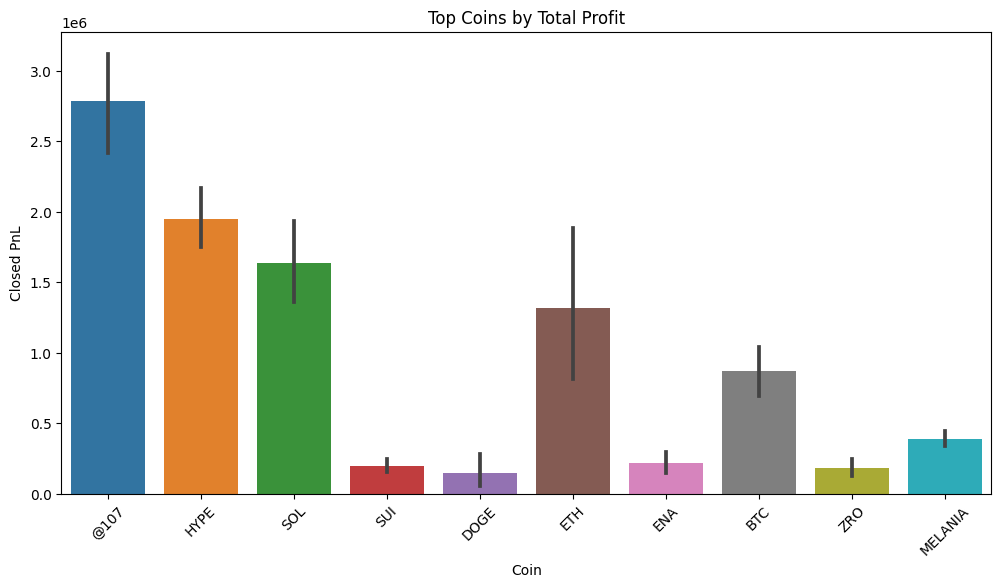

In [71]:
#Plot top coins
top_coins = (
    merged.groupby("Coin")["Closed PnL"]
    .sum()
    .nlargest(10)
    .index
)

plot_data = merged[
    merged["Coin"].isin(top_coins)
]

plt.figure(figsize=(12,6))

sns.barplot(
    data=plot_data,
    x="Coin",
    y="Closed PnL",
    estimator=sum
)

plt.title("Top Coins by Total Profit")

plt.xticks(rotation=45)

plt.show()

# Key Finding
Profitability varied across traded assets, indicating that market sentiment alone does not explain trading performance. Certain coins consistently contributed more to trader profits than others.

## 4. Statistical tests

We formally test whether daily total PnL and win rates differ across 
sentiment regimes, and which regimes are significantly different.

In [72]:
from scipy import stats
# Kruskal–Wallis for total PnL
groups_pnl = [
    daily[daily["classification"] == c]["total_pnl"].dropna()
    for c in ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
]
stat_pnl, p_pnl = stats.kruskal(*groups_pnl)
print(f"Kruskal–Wallis for total PnL across sentiment: H={stat_pnl:.3f}, p={p_pnl:.4f}")

# Kruskal–Wallis for win rate
groups_wr = [
    daily[daily["classification"] == c]["win_rate"].dropna()
    for c in ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
]
stat_wr, p_wr = stats.kruskal(*groups_wr)
print(f"Kruskal–Wallis for win rate across sentiment: H={stat_wr:.3f}, p={p_wr:.4f}")

Kruskal–Wallis for total PnL across sentiment: H=20.058, p=0.0005
Kruskal–Wallis for win rate across sentiment: H=19.959, p=0.0005


## Key finding
The Kruskal–Wallis tests indicate statistically significant differences in both daily profitability and win rates across market sentiment categories (p < 0.001). This provides statistical evidence that trader performance varies with Bitcoin market sentiment rather than occurring by random chance.

## 5 Summary 
During Fear and Extreme Fear periods, traders generated higher average profits and substantially higher trading volumes. Although BUY and SELL activity remained relatively balanced across sentiment regimes, trading outcomes differed significantly, suggesting that market timing and disciplined execution are more important than directional bias.

## 6. Limitations and further work

This analysis is based only on historical data, so the same pattern may not always hold in the future.

I also did not go very deep into coin-specific behavior or leverage effects. A stronger next step would be to compare major coins with smaller coins, and to study how leverage or liquidation events change across sentiment levels.